# ETC Survey Reconciliation



Approach: 

### Import Dependancies

In [238]:
#!pip install yellowbrick
#!pip install kneed

In [252]:
import pandas as pd
import numpy as np
from IPython.display import display
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from bertopic import BERTopic



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

import math
import os
import warnings


# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tiruskimani/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tiruskimani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Data Loading and Inspection


In [253]:
print(os.getcwd())
input_dir = os.path.join(os.getcwd(), 'MSDATA/capstone/etc_database_recon/input')
output_dir = os.path.join(os.getcwd(), 'MSDATA/capstone/etc_database_recon/output')
print(input_dir)
print(output_dir)
# Define file paths
dallas_path = os.path.join(input_dir, 'KSU/Dallas_TX.csv');

johnson_path = os.path.join(input_dir, 'KSU/Johnston_IA.csv');
olathe_path = os.path.join(input_dir, 'KSU/Olathe_KS.csv');
overland_path = os.path.join(input_dir, 'KSU/Overland Park_KS.csv');
riviera_path = os.path.join(input_dir, 'KSU/Riviera Beach_FL.csv');
towards_template_path = os.path.join(input_dir, 'KSU/TowardsGenericSurvey.csv');
towards_template_sample_path = os.path.join(input_dir, 'KSU/TowardsGenericSurvey.csv');

low_match_csv_path = os.path.join(output_dir, 'low_matched_survey_questions.csv');
medium_match_csv_path = os.path.join(output_dir, 'medium_matched_survey_questions.csv');
high_match_csv_path = os.path.join(output_dir, 'high_matched_survey_questions.csv');
grouped_questions_csv_path = os.path.join(output_dir, 'grouped_survey_questions.csv');

cleaned_survey_csv_path = os.path.join(output_dir, 'cleaned_survey_questions.csv');
survey_questions_with_embeddings_csv_path = os.path.join(output_dir, 'survey_questions_with_embeddings.csv');
survey_questions_with_topics_csv_path = os.path.join(output_dir, 'survey_questions_with_topics.csv');
similarity_matrix_npy_path = os.path.join(output_dir, 'similarity_matrix.npy');
clustered_questions_csv_path = os.path.join(output_dir, 'clustered_questions.csv');

RawGenericSurvey_csv_path = os.path.join(output_dir, 'RawGenericSurvey.csv');
GenericSurvey_csv_path = os.path.join(output_dir, 'GenericSurvey.csv');
RefinedSurvey_csv_path = os.path.join(output_dir, 'RefinedSurvey.csv');

similarity_scores_csv_path = os.path.join(output_dir, 'similarity_scores.csv');

# Load the datasets
dallas_df = pd.read_csv(dallas_path)
johnson_df = pd.read_csv(johnson_path)
olathe_df = pd.read_csv(olathe_path)
overland_df = pd.read_csv(overland_path)
riviera_df = pd.read_csv(riviera_path)

# Load generic sample
towards_generic_sample_df = pd.read_csv(towards_template_sample_path)

# Load generic template
towards_generic_df = pd.read_csv(towards_template_path)



# Display the first few rows of each dataset
# dallas_df.head(), johnson_df.head(),olathe_df.head(),overland_df.head(),riviera_df.head(),towards_df.head()


city_names = ['dallas','olathe','overland park','johnson','Johnston','riviera beach','riviera','kansas city']

/Users/tiruskimani
/Users/tiruskimani/MSDATA/capstone/etc_database_recon/input
/Users/tiruskimani/MSDATA/capstone/etc_database_recon/output


In [246]:
dallas_df.sample(20)

,Response ID,Date submitted,Last page,Start language,Seed,Date started,Date last action,SURVEYINFO[ComName][Q].Enter community name and state into Default Values Grid [],SURVEYINFO[ST][Q].Enter community name and state into Default Values Grid [],SURVEYINFO[YR][Q].Enter community name and state into Default Values Grid [],...,Q29[L].What is your total annual household income?,Q29[L].What is your total annual household income?.1,Q30[L].Do you own or rent your home?,Q30[L].Do you own or rent your home?.1,Q31[L].Are you or is anyone in your household disabled?,Q31[L].Are you or is anyone in your household disabled?.1,Q32[L].Are you or is anyone in your household a member of the LGBTQ+ community?,Q32[L].Are you or is anyone in your household a member of the LGBTQ+ community?.1,Q33[L].Would you be willing to participate in future surveys sponsored by the City of {INSERTANS:8245X10302X182318ComName}?,Q33[L].Would you be willing to participate in future surveys sponsored by the City of {INSERTANS:8245X10302X182318ComName}? .1
5219,5353,NaN,4,en,1.212440e+09,5/24/2024 0:08,5/24/2024 0:08,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,164,NaN,4,en,2.424369e+08,3/28/2024 12:42,3/28/2024 12:42,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5021,5155,5/19/2024 1:04,12,en,1.423598e+09,5/19/2024 0:10,5/19/2024 1:04,Dallas,TX,2024.0,...,5.0,"$100,000 or more",2.0,Rent (or occupy without paying),2.0,No,1.0,Yes,1.0,Yes
3105,3205,4/18/2024 15:12,12,en,3.515288e+08,4/18/2024 14:46,4/18/2024 15:12,Dallas,TX,2024.0,...,NaN,NaN,1.0,Own,2.0,No,2.0,No,1.0,Yes
1754,1843,NaN,6,en,1.976767e+09,4/4/2024 10:52,4/4/2024 11:00,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1440,1526,4/2/2024 2:01,12,en,2.552494e+08,4/2/2024 1:43,4/2/2024 2:01,Dallas,TX,2024.0,...,2.0,"$25,000 - $49,999",1.0,Own,2.0,No,2.0,No,1.0,Yes
2973,3072,NaN,4,en,1.089434e+09,4/17/2024 23:14,4/17/2024 23:14,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
733,814,3/30/2024 15:12,12,en,1.377742e+09,3/30/2024 14:58,3/30/2024 15:12,Dallas,TX,2024.0,...,3.0,"$50,000 - $74,999",2.0,Rent (or occupy without paying),2.0,No,2.0,No,2.0,No
3627,3738,4/22/2024 17:19,12,en,5.379660e+08,4/22/2024 1:46,4/22/2024 17:19,Dallas,TX,2024.0,...,5.0,"$100,000 or more",1.0,Own,1.0,Yes,2.0,No,1.0,Yes
3489,3597,NaN,4,en,1.333857e+09,4/21/2024 4:22,4/21/2024 4:22,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [247]:
# View Sample generic survey template
towards_generic_sample_df.sample(5)

,Group,Group Notes,Question,Question Type,Question Notes,Answer Option 1,Answer Option 2,Answer Option 3,Answer Option 4,Answer Option 5,...,Z-axis Option 3,Z-axis Option 4,Z-axis Option 5,Z-axis Option 6,Z-axis Option 7,Z-axis Option 8,Z-axis Option 9,Z-axis Option 10,Z-axis Option 11,Z-axis Option 12
20,Demograpics,NaN,Approximately how many years have you lived in...,Short free text,NaN,Years:,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,Demograpics,NaN,Your gender,List (Radio),CreatedBy: System Message: Please describe other.,Male,Female,I prefer to self-identify,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,Customer Satisfaction,NaN,What do you like most about living in City Name?,Short free text,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,Demograpics,NaN,Are you or any members of your family of Hispanic,Spanish,or Latino/a/x ancestry?,List with comment,NaN,Yes: ______ people,No:,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Customer Satisfaction,NaN,Please rate your satisfaction with each of the...,Array by column,NaN,Very Easy\t,Easy\t,Neutral\t,Difficult\t,Very Difficult\t,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [248]:
# view Generated generic survey template
towards_generic_df.sample(10)

,Group,Group Notes,Question,Question Type,Question Notes,Answer Option 1,Answer Option 2,Answer Option 3,Answer Option 4,Answer Option 5,...,Z-axis Option 3,Z-axis Option 4,Z-axis Option 5,Z-axis Option 6,Z-axis Option 7,Z-axis Option 8,Z-axis Option 9,Z-axis Option 10,Z-axis Option 11,Z-axis Option 12
23,Demograpics,NaN,Your gender,List (Radio),CreatedBy: System Message: Please describe other.,Male,Female,I prefer to self-identify,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Demograpics,NaN,Including yourself,how many people in your household are,List (Radio),NaN,Under age 5,Ages 5-9,Ages 10-14,Ages 15-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Customer Satisfaction,NaN,Please rate the Village of Gurnee on a scale o...,"where 5 means ""Excellent"" and 1 means ""Poor"" ...",Array by column,NaN,Excellent\t,Good\t,Neutral\t,Below Average\t,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Customer Satisfaction,NaN,Please rate your satisfaction with each of the...,"where 5 means ""Very Satisfied"" and 1 means ""V...",Array by column,NaN,Very Satisfied\t,Satisfied\t,Neutral\t,Dissatisfied\t,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,Demograpics,NaN,Which of the following best describes your rac...,Multiple choice,CreatedBy: System Message: ETC Standard order,Asian or Asian Indian,Black or African American,American Indian or Alaska Native,White,Hispanic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Customer Satisfaction,NaN,Please rate the ease of use of the following.,Array by column,NaN,Very Easy\t,Easy\t,Neutral\t,Difficult\t,Very Difficult\t,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,Customer Satisfaction,NaN,If there is one thing that you could change ab...,what would it be and why?,Short free text,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Customer Satisfaction,NaN,Which THREE of the services listed in Question...,"or circle ""NONE.""]",Short free text,NaN,1st:,2nd:,3rd:,NONE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,Demograpics,NaN,Would you say your total annual household inco...,List (Radio),NaN,Under $30,000,$30,000 to $49,999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Customer Satisfaction,NaN,From which TWO sources of information listed i...,"or circle ""NONE.""]",List (Radio),NaN,1st:,2nd:,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing


### Handle Duplicates

In [249]:
def merge_and_keep_second(df):
    # Identify unique question prefixes, ignoring duplicate numbering.
    # This creates a mapping from the base name to all matching columns.
    column_map = {}
    for col in df.columns:
        base_name = re.sub(r"\.\d+$", "", col)  # Remove trailing .number (e.g., ".1")
        if base_name not in column_map:
            column_map[base_name] = [col]  # Start with the first occurrence
        else:
            column_map[base_name].append(col)  # Append duplicates

    final_df = pd.DataFrame()

    for base_name, cols in column_map.items():
        # If duplicate columns exist, keep the second column (if it exists)
        if len(cols) > 1:
            final_df[base_name] = df[cols[1]]
        else:
            final_df[base_name] = df[cols[0]]  # Only one column available, so keep it

    return final_df

In [254]:
# Perform handling of dups
dallas_df = merge_and_keep_second(dallas_df)
johnson_df = merge_and_keep_second(johnson_df)
olathe_df = merge_and_keep_second(olathe_df)
overland_df = merge_and_keep_second(overland_df)
riviera_df = merge_and_keep_second(riviera_df)

In [255]:
# combine the  Data
merged_df = pd.concat([dallas_df, olathe_df, overland_df,riviera_df,johnson_df], axis=0, ignore_index=True)

In [256]:
merged_df.head()

,Response ID,Date submitted,Last page,Start language,Seed,Date started,Date last action,SURVEYINFO[ComName][Q].Enter community name and state into Default Values Grid [],SURVEYINFO[ST][Q].Enter community name and state into Default Values Grid [],SURVEYINFO[YR][Q].Enter community name and state into Default Values Grid [],...,"Q42[04][K].Counting yourself, how many people in your household are… [Ages 15-19:]","Q42[05][K].Counting yourself, how many people in your household are… [Ages 20-24:]","Q42[06][K].Counting yourself, how many people in your household are… [Ages 25-34:]","Q42[07][K].Counting yourself, how many people in your household are… [Ages 35-44:]","Q42[08][K].Counting yourself, how many people in your household are… [Ages 45-54:]","Q42[09][K].Counting yourself, how many people in your household are… [Ages 55-64:]","Q42[10][K].Counting yourself, how many people in your household are… [Ages 65-74:]","Q42[11][K].Counting yourself, how many people in your household are… [Ages 75+:]",Q43[L].Do you own or rent your current residence?,Q44[L].Your gender:
0,66,NaN,4,es,1.055208e+09,3/10/2024 2:57,3/10/2024 2:57,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,67,NaN,4,en,1.670632e+09,3/10/2024 10:40,3/10/2024 10:40,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68,NaN,4,es,9.939355e+08,3/10/2024 14:01,3/10/2024 14:01,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,69,NaN,4,en,9.671170e+07,3/10/2024 15:17,3/10/2024 15:17,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,70,NaN,4,en,1.576600e+09,3/10/2024 22:33,3/10/2024 22:33,Dallas,TX,2024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Question Cleaning: Standardize survey questions, remove metadata, and clean text.

In [257]:
# clean column names
def clean_column_names_pipeline(column_list):
    cleaned_columns = (
        pd.Series(column_list)
        .str.split('.', n=1).str[-1]  # Remove everything before the first '.'
        # .str.replace('.', '-', regex=False)  # Replace remaining '.' with '-'
        .str.replace(r'__+', '_', regex=True)  # Remove double underscores
        .str.replace(r'[^\w\s_-]', '', regex=True)  # Remove all punctuation except '_' and '-'
        .str.replace(r'\s+', ' ', regex=True)  # Remove extra whitespace
        .str.strip()  # Remove leading/trailing spaces
        .str.lower()  # Convert to lowercase
    )
    return cleaned_columns.tolist()


In [258]:
# Extract questions targeting where column names start with 'Q'
unique_questions_dallas = [col for col in dallas_df.columns if col.strip().lower().startswith("q")]
unique_questions_johnson = [col for col in johnson_df.columns if col.strip().lower().startswith("q")]
unique_questions_olathe = [col for col in olathe_df.columns if col.strip().lower().startswith("q")]
unique_questions_overland = [col for col in overland_df.columns if col.strip().lower().startswith("q")]
unique_questions_riviera = [col for col in riviera_df.columns if col.strip().lower().startswith("q")]

In [259]:
# break down questions into parts,we preserve . in ()
def split_question(question):
    # Temp replace .  inside () with a placeholder
    question_temp = re.sub(r"\(([^)]+)\)", lambda m: m.group(0).replace('.', '<PERIOD>'), question)

    # Split using ./? that is not before by a number
    parts = re.split(r'(?<!\d)[.?]', question_temp)

    # now restore original . inside ()
    parts = [part.replace('<PERIOD>', '.') for part in parts]

    # strip whitespace
    parts = [part.strip() for part in parts if part.strip()]

    return parts

In [260]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = word_tokenize(text)  # Tokenize words
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    return " ".join(tokens)


# clean and extract question parts
def clean_and_split_questions(df,questions):
    cleaned_data = []

    for question in questions:
        
        
        parts = split_question(question)
        
        print("PARTS:",parts)
        # Extract question from parts
        question_number = parts[0] if len(parts) > 0 else ""
        question_head_prompt = parts[1].strip() if len(parts) > 3 else ""
        question_body_prompt = parts[2].strip() if len(parts) > 3 else parts[1].strip() 
        question_tail_prompt = re.search(r"\[(.*?)\]", parts[-1])  # Extract text inside brackets []

        # Get specificification question if it exists
        question_tail_prompt = question_tail_prompt.group(1) if question_tail_prompt else ""
     
     
       # clean
        question_head_prompt = clean_text(question_head_prompt)
        question_body_prompt = clean_text(question_body_prompt)
        question_tail_prompt = clean_text(question_tail_prompt)
        
        
        # Replace city names with "[city name] placehoder"
        for city in city_names:
            if question_head_prompt:
                question_head_prompt = re.sub(rf"\b{city}\b", "[city name]", question_head_prompt, flags=re.IGNORECASE)
            if question_body_prompt:
                question_body_prompt = re.sub(rf"\b{city}\b", "[city name]", question_body_prompt, flags=re.IGNORECASE)
            if question_tail_prompt:
                question_tail_prompt = re.sub(rf"\b{city}\b", "[city name]", question_tail_prompt, flags=re.IGNORECASE)
        
      
        
        
        
        # Grab unique answer options for the question across all rows from the merged dataset
        answer_options = df[question].dropna().unique().tolist() if question in df.columns else []

        print("answer_options:",answer_options)
        # save answer option in columns
        max_options = 10  # maximum number of columns for the options
        option_columns = {f"option_{i+1}": (answer_options[i] if i < len(answer_options) else None) for i in range(max_options)}
     
                
        # Store cleaned components
        cleaned_data.append({
            "question_number": question_number,
            "question_head_prompt": question_head_prompt,
            "question_body_prompt": question_body_prompt,
            "question_tail_prompt": question_tail_prompt,
            **option_columns

        })
        

    return pd.DataFrame(cleaned_data)

In [263]:
# Perform cleaning and extraction

all_questions = sum([unique_questions_dallas,unique_questions_olathe, unique_questions_johnson,unique_questions_overland,unique_questions_riviera], [])

cleaned_all_questions = clean_and_split_questions(merged_df,all_questions)


# Drop duplicate rows
# cleaned_df = cleaned_df.drop_duplicates(subset=['question_number'], keep='last')


# Save structured data
cleaned_all_questions.to_csv(cleaned_survey_csv_path, index=False)

# Display cleaned questions
display(cleaned_all_questions.head(20))


PARTS: ['Q1[01][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[01. Dallas as a place to live]']
answer_options: ['Good', 'Fair', 'Excellent', 'Poor', "Don't Know"]
PARTS: ['Q1[02][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[02. Your neighborhood as a place to live]']
answer_options: ['Good', 'Excellent', 'Fair', 'Poor', "Don't Know"]
PARTS: ['Q1[03][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[03. Dallas as a place to raise children]']
answer_options: ['Good', 'Excellent', "Don't Know", 'Poor', 'Fair']
PARTS: ['Q1[04][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[04. Dallas as a place to work]']
answer_options: ['Excellent', 'Good', 'Poor', 'Fair', "Don't Know"]
PARTS: ['Q1[05][F]', 'Perceptions of the City', 'Please rate th

,question_number,question_head_prompt,question_body_prompt,question_tail_prompt,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
0,Q1[01][F],perceptions city,please rate following items circling correspon...,01 [city name] place live,Good,Fair,Excellent,Poor,Don't Know,None,None,None,None,None
1,Q1[02][F],perceptions city,please rate following items circling correspon...,02 neighborhood place live,Good,Excellent,Fair,Poor,Don't Know,None,None,None,None,None
2,Q1[03][F],perceptions city,please rate following items circling correspon...,03 [city name] place raise children,Good,Excellent,Don't Know,Poor,Fair,None,None,None,None,None
3,Q1[04][F],perceptions city,please rate following items circling correspon...,04 [city name] place work,Excellent,Good,Poor,Fair,Don't Know,None,None,None,None,None
4,Q1[05][F],perceptions city,please rate following items circling correspon...,05 [city name] place retire,Fair,Poor,Excellent,Don't Know,Good,None,None,None,None,None
5,Q1[06][F],perceptions city,please rate following items circling correspon...,06 [city name] place business,Excellent,Good,Fair,Don't Know,Poor,None,None,None,None,None
6,Q1[07][F],perceptions city,please rate following items circling correspon...,07 [city name] place feel welcome,Excellent,Good,Fair,Poor,Don't Know,None,None,None,None,None
7,Q1[08][F],perceptions city,please rate following items circling correspon...,08 quality economic development [city name],Good,Fair,Poor,Excellent,Don't Know,None,None,None,None,None
8,Q1[09][F],perceptions city,please rate following items circling correspon...,09 overall quality life [city name],Fair,Good,Poor,Excellent,Don't Know,None,None,None,None,None
9,Q1[10][F],perceptions city,please rate following items circling correspon...,10 overall value receive city property tax dol...,Good,Poor,Fair,Excellent,Don't Know,None,None,None,None,None


#### Prepare data for modelling

In [264]:
cleaned_all_questions.head()

,question_number,question_head_prompt,question_body_prompt,question_tail_prompt,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
0,Q1[01][F],perceptions city,please rate following items circling correspon...,01 [city name] place live,Good,Fair,Excellent,Poor,Don't Know,None,None,None,None,None
1,Q1[02][F],perceptions city,please rate following items circling correspon...,02 neighborhood place live,Good,Excellent,Fair,Poor,Don't Know,None,None,None,None,None
2,Q1[03][F],perceptions city,please rate following items circling correspon...,03 [city name] place raise children,Good,Excellent,Don't Know,Poor,Fair,None,None,None,None,None
3,Q1[04][F],perceptions city,please rate following items circling correspon...,04 [city name] place work,Excellent,Good,Poor,Fair,Don't Know,None,None,None,None,None
4,Q1[05][F],perceptions city,please rate following items circling correspon...,05 [city name] place retire,Fair,Poor,Excellent,Don't Know,Good,None,None,None,None,None


In [265]:

# Merge 'question_body_prompt' and 'question_tail_prompt' into a single string per question
cleaned_all_questions['merged_question_text'] = cleaned_all_questions[['question_body_prompt', 'question_tail_prompt']].astype(str).agg(' '.join, axis=1)
# Extract the merged question text into a list
cleaned_survey_questions = cleaned_all_questions['merged_question_text'].dropna().tolist()
cleaned_survey_questions_group = cleaned_all_questions['question_head_prompt'].dropna().tolist()


# Ensure all_questions has the same length as cleaned_survey_questions
if len(all_questions) == len(cleaned_survey_questions):
    # Combine original questions and cleaned questions into a single DataFrame
    cleaned_survey_questions_df = pd.DataFrame({"question_group":cleaned_survey_questions_group,"original_question": all_questions, "cleaned_question": cleaned_survey_questions})
else:
    print("Error: Length of all_questions and cleaned_survey_questions do not match!")


cleaned_survey_questions_df['cleaned_question'] = cleaned_survey_questions_df['cleaned_question'].replace(['None',None,'none'], '')

In [268]:
cleaned_survey_questions_df.sample(20)

,question_group,original_question,cleaned_question
140,code enforcement services,Q13[07][F].Code Enforcement Services. Please r...,please rate citys performance following areas ...
70,major categories city services,Q7[12][M].Major Categories of City Services. P...,please indicate whether member household used ...
213,,Q28[L].What is the primary language spoken in ...,primary language spoken home
376,please answer either yes following questions,"Q23[09][F].Please answer either ""Yes"" or ""No"" ...",09 household members visited indooroutdoor cit...
445,,Q10[08][F].Please rate your satisfaction with ...,please rate satisfaction park services listed ...
483,,Q18a[01][F].Please rate your satisfaction with...,please rate satisfaction following items 1 qua...
516,,Q22[01][F].Please indicate how the City of Joh...,please indicate city [city name] compares citi...
47,,"Q5x14[T].Please define ""Other.""",please define
106,public safety services,Q9[02][F].Public Safety Services. Please rate ...,please rate citys performance following areas ...
337,,Q19[03][F].Please rate Olathe with regard to e...,please rate [city name] regard following 3 pla...


In [269]:
print(len(cleaned_survey_questions_df))

925


### Topic Modeling Using LDA & BERTopic

##### Convert survey questions into numerical vectors using CountVectorizer/TFIDF.

In [270]:
from sklearn.feature_extraction.text import CountVectorizer
# Vectorize text
vectorizer = CountVectorizer(stop_words='english')
dtm = vectorizer.fit_transform(cleaned_survey_questions_df['cleaned_question'])

#####  Convert survey questions into numerical vectors using Sentence-BERT (SBERT).

In [272]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load Sentence-BERT model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

# Compute sentence embeddings for each question
cleaned_survey_questions_df["sbert_embedding"] = cleaned_survey_questions_df["cleaned_question"].apply(
    lambda x: sbert_model.encode(x).tolist()
)

# Save embeddings
cleaned_survey_questions_df.to_csv(survey_questions_with_embeddings_csv_path, index=False)

print("✅ Sentence Embeddings Computed & Saved!")

✅ Sentence Embeddings Computed & Saved!


In [273]:
# Categorize broad topics across all survey questions.
from sklearn.decomposition import LatentDirichletAllocation
from bertopic import BERTopic


# Apply LDA Topic Modeling
lda_model = LatentDirichletAllocation(n_components=10, random_state=0)
lda_topics = lda_model.fit_transform(dtm)

# Assign most probable topic to each question
topic_assignments = lda_topics.argmax(axis=1)
cleaned_survey_questions_df["lda_topic"] = topic_assignments

# Apply BERTopic (more powerful for short text clustering)
bertopic_model = BERTopic()
bertopic_topics, _ = bertopic_model.fit_transform(cleaned_survey_questions_df['cleaned_question'].tolist())

# Assign BERTopic topics
cleaned_survey_questions_df["bertopic_topic"] = bertopic_topics

# Save with topics
cleaned_survey_questions_df.to_csv(survey_questions_with_topics_csv_path, index=False)

print("✅ Topic modeling applied and saved!")


✅ Topic modeling applied and saved!


#### Compute Pairwise Similarity using Cosine Distance

In [274]:
survey_questions_df = cleaned_survey_questions_df

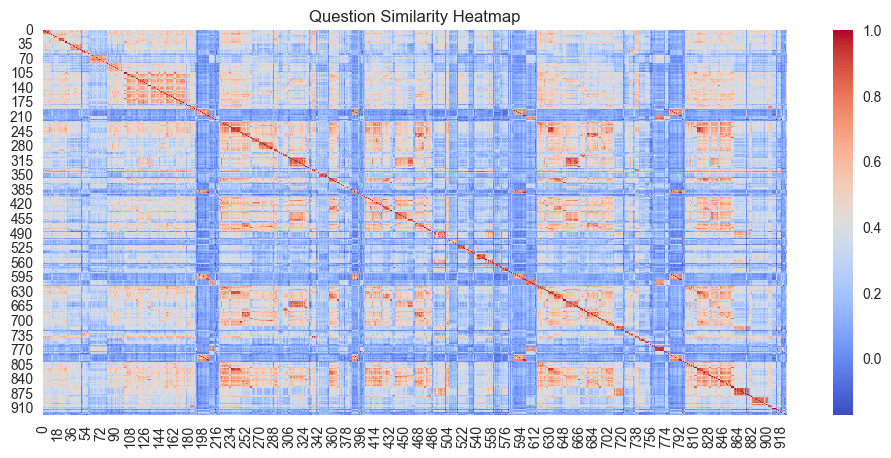

 Similarity Matrix Computed & Saved!


In [275]:

# Find similar questions by computing Cosine Similarity.
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns


# Convert embeddings to numpy array
question_embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(question_embeddings)

# plot correlation heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(similarity_matrix, cmap="coolwarm", annot=False)
plt.title("Question Similarity Heatmap")
plt.show()


# Save similarity matrix
np.save(similarity_matrix_npy_path, similarity_matrix)

print(" Similarity Matrix Computed & Saved!")


In [276]:
display(similarity_matrix)

array([[ 1.        ,  0.89268252,  0.8347344 , ...,  0.13529468,
        -0.00907936,  0.47048241],
       [ 0.89268252,  1.        ,  0.81194473, ...,  0.18936501,
         0.03222209,  0.37315722],
       [ 0.8347344 ,  0.81194473,  1.        , ...,  0.16939428,
         0.14049806,  0.41192827],
       ...,
       [ 0.13529468,  0.18936501,  0.16939428, ...,  1.        ,
         0.18209551,  0.00592558],
       [-0.00907936,  0.03222209,  0.14049806, ...,  0.18209551,
         1.        , -0.01241543],
       [ 0.47048241,  0.37315722,  0.41192827, ...,  0.00592558,
        -0.01241543,  1.        ]])

##  Cluster Questions Using Hierarchical Clustering

In [277]:
# Convert to DataFrame
df_questions = pd.DataFrame(survey_questions_df, columns=["cleaned_question"])

# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(stop_words="english")
question_embeddings = vectorizer.fit_transform(df_questions["cleaned_question"])
question_embeddings = question_embeddings.toarray()

print("Vector dimensions",question_embeddings.shape)

Vector dimensions (925, 1075)


In [ ]:
# question_embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())
# print("Vector dimensions",question_embeddings.shape)

### Find Best Optimal K

In [278]:
N = len(cleaned_survey_questions)  
# max_k = use the square root of total questions
#max_k =  math.ceil(math.sqrt(N)) + 10
# max_k = use 10% of total questions
max_k = int(0.1 * N)

##### Find Best Optimal K based on WCSS(Within-Cluster Sum of Squares/Total Sum of Squares)  & silhouette score,  with capped max_k(sqrt) 

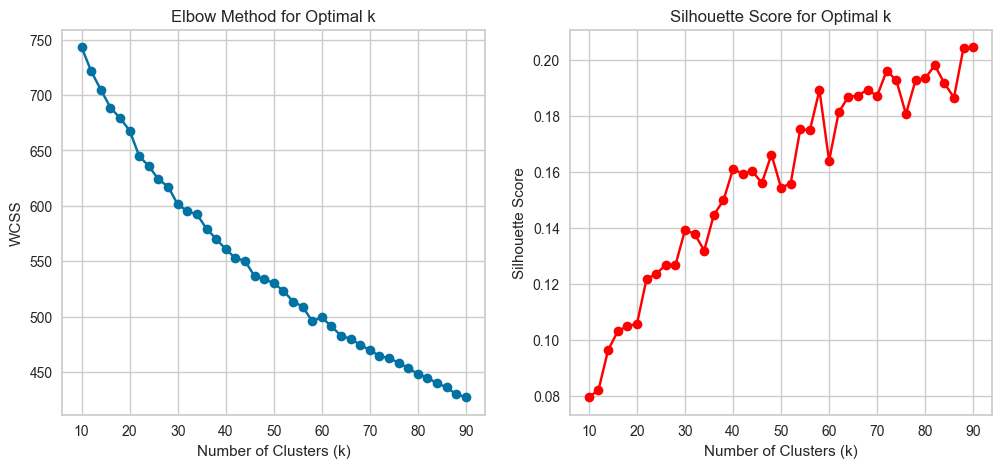

Max k: 92
Optimal Number of Clusters: 90


In [279]:
### Step 1: Find Optimal `k` Using the Elbow Method- Identifies the point where adding more clusters doesn't significantly reduce the intra-cluster variance.

wcss = []  # Within-Cluster Sum of Squares
sil_scores = []


K_range = range(10, max_k ,2)  # Avoid k > num_questions, Testing different k values : starting at 10 clusters, step up by 2 for compute efficiency
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(question_embeddings)
    
    wcss.append(kmeans.inertia_)  # Inertia (WCSS)
    
    # Compute silhouette score- Silhouette Score – Measures how well each point fits within its assigned cluster
    sil_score = silhouette_score(question_embeddings, kmeans.labels_)
    sil_scores.append(sil_score)

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker="o", color="red")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")

plt.show()

optimal_k = K_range[np.argmax(sil_scores)]  # Pick the best `k` based on silhouette score

print(f"Max k: {max_k}")
print(f"Optimal Number of Clusters: {optimal_k}")

##### Find Best Optimal K based on distortions (average sum of squared distances) & silhouette score,  with capped max_k (sqrt)

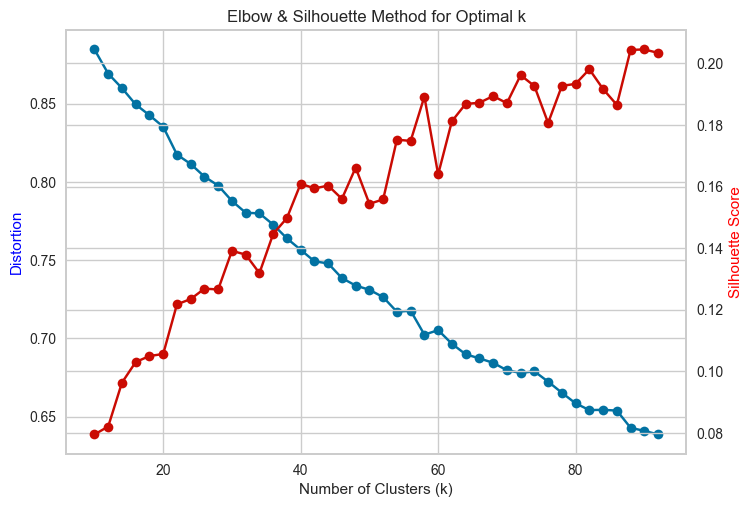

Max k: 92
Optimal K: 90


In [280]:



### Find Optimal K Using Elbow Method**
def find_optimal_k(embeddings, max_k):
    distortions = []  # measure how spread out the clusters are : lower distortion means clusters are compact
    silhouette_scores = []
    K_range = range(10, max_k + 1, 2)  # Testing different k values : starting at 10 clusters, step up by 2 for compute efficiency

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=0, n_init=10) # n_init: run the kmeans algo n times with different centroids to impove chances of finding a good cluster
        kmeans.fit(embeddings)
        distortions.append(sum(np.min(cdist(embeddings, kmeans.cluster_centers_, 'euclidean'), axis=1)) / embeddings.shape[0])
        silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))
    
    
    optimal_k = K_range[np.argmax(silhouette_scores)]  # Pick the best `k` based on silhouette score
    # Plot Elbow & Silhouette Scores
    fig, ax1 = plt.subplots()

    ax2 = ax1.twinx()
    ax1.plot(K_range, distortions, 'bo-', label="Distortion (Elbow)")
    ax2.plot(K_range, silhouette_scores, 'ro-', label="Silhouette Score")

    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Distortion", color="blue")
    ax2.set_ylabel("Silhouette Score", color="red")
    plt.title("Elbow & Silhouette Method for Optimal k")
    plt.show()
    return optimal_k




optimal_k = find_optimal_k(question_embeddings, max_k) # max_k : test upto n clusters to ensure we cover a broad range and dont miss a potential optimal number

print(f"Max k: {max_k}")
print(f"Optimal K: {optimal_k}")

#### Charts interpretation

Based on the chart, the silhouette score keeps rising and distortion keeps falling as k increases. 
Although we don’t see a single sharp ‘elbow,’ the silhouette appears to reach a high value near k=45–60. At that point, distortion is already quite low, and adding more clusters beyond 50 doesn’t dramatically increase the silhouette score. Therefore, k ≈ 45–60 is likely a good balance between compact, well-separated clusters and practical manageability.

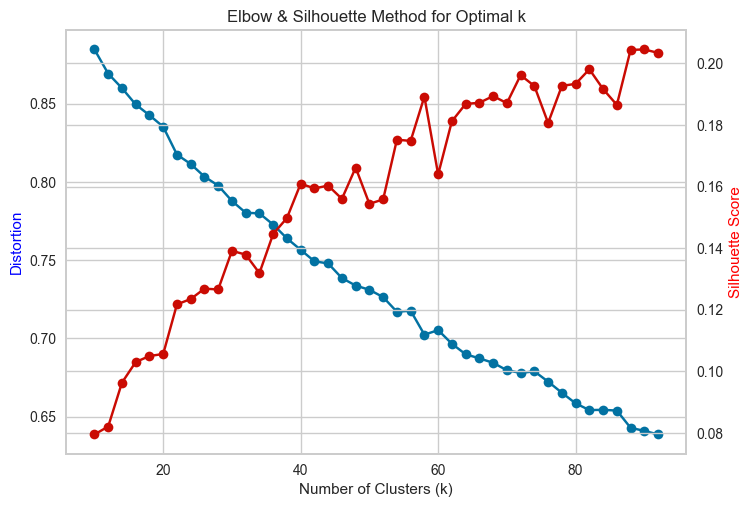

Max k: 92
Optimal k (via knee locator): 54


In [281]:
from kneed import KneeLocator

def find_optimal_k_with_knee(embeddings, max_k):
    distortions = []  # To store average distortion values for each k
    silhouette_scores = []
    K_range = list(range(10, max_k + 1, 2))  # Testing different k values

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
        kmeans.fit(embeddings)
        # Calculate average distortion (average minimum distance to centroids)
        distortion = sum(np.min(cdist(embeddings, kmeans.cluster_centers_, 'euclidean'), axis=1)) / embeddings.shape[0]
        distortions.append(distortion)
        silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))

    # Use KneeLocator to identify the "elbow" in the distortion curve
    # Since distortion is convex and decreasing, set curve='convex' and direction='decreasing'
    kneedle = KneeLocator(K_range, distortions, curve='convex', direction='decreasing')
    optimal_k = kneedle.knee

    # Optional: Plot the results to visually verify the knee
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(K_range, distortions, 'bo-', label="Distortion (Elbow)")
    ax2.plot(K_range, silhouette_scores, 'ro-', label="Silhouette Score")
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Distortion", color="blue")
    ax2.set_ylabel("Silhouette Score", color="red")
    plt.title("Elbow & Silhouette Method for Optimal k")
    plt.show()

    return optimal_k

optimal_k_knee = find_optimal_k_with_knee(question_embeddings, max_k)
print(f"Max k: {max_k}")
print(f"Optimal k (via knee locator): {optimal_k_knee}")


In [282]:
optimal_k_knee

54

In [283]:
# we set optimal k at elbow
optimal_k_visual = 55
optimal_k_knee_predicted = optimal_k_knee

#### Feature Separation to enhance KMeans : Dimensionality reduction

##### PCA to Improve Feature Separation Before Clustering - To reduce high demensional TF-IDF vectors into lower-dimensional space while retaining most of variance -keep important info.

##### Cumulative Explained Variance Plot


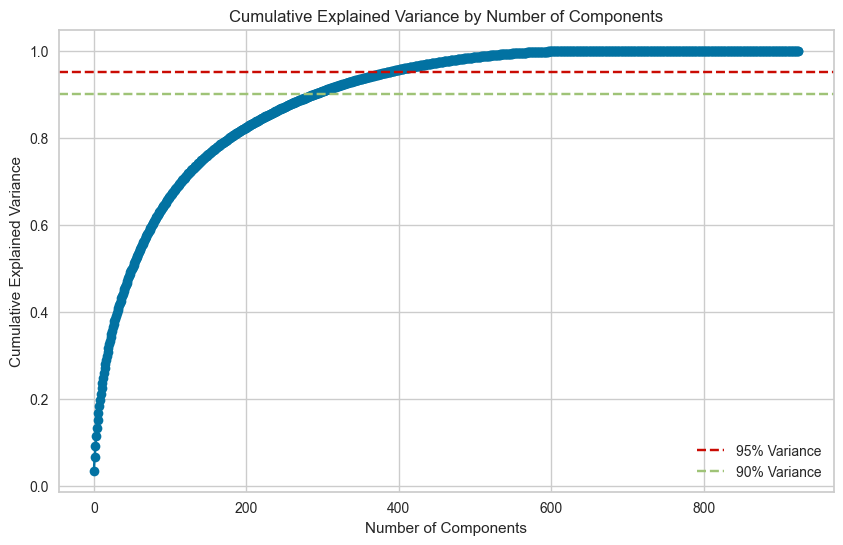

In [284]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Fit PCA without reducing dimensions first
pca_full = PCA()
pca_full.fit(question_embeddings)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance')
plt.legend()
plt.title("Cumulative Explained Variance by Number of Components")
plt.show()

#### Calculate the Knee/elbow value, to detect suitable n_components while retaining variance

In [285]:
from kneed import KneeLocator

# Assuming cumulative_variance and component indices are computed as above:
x = np.arange(1, len(cumulative_variance) + 1)
kneedle = KneeLocator(x, cumulative_variance, curve='concave', direction='increasing')
optimal_components = kneedle.knee
print("Optimal number of components:", optimal_components)


Optimal number of components: 201


In [286]:
n_components = optimal_components
n_components_fixed = 20

In [287]:
# Keep enough components to explain 95% of the variance
pca = PCA(n_components) # 95% - Reduce dimensions from original to reduce noise/keep important only/remove redundant features
embeddings_pca = pca.fit_transform(question_embeddings)
print("Number of components chosen to retain most of variance:", pca.n_components_)

Number of components chosen to retain most of variance: 201


## Clustering

### 1. KMeans Clustering

##### Perform kmeans clustering on the PCA transformations and Optimal K

In [288]:
# Run K-Means with Optimal k
## optimal_k - Choosen based on visual analysis from the Elbow & Silhouette score
## optimal_k_knee_predicted - Automatically chosen using kneeLocator on distortions
best_k = optimal_k_knee_predicted  # optimal_k 
# best_k = 100
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_pca) # partition the question data into meaningful groups (clusters)

In [289]:
best_k

54

##### Visualizing Clusters with t-SNE (t-distributed Stochastic Neighbour Embedding)

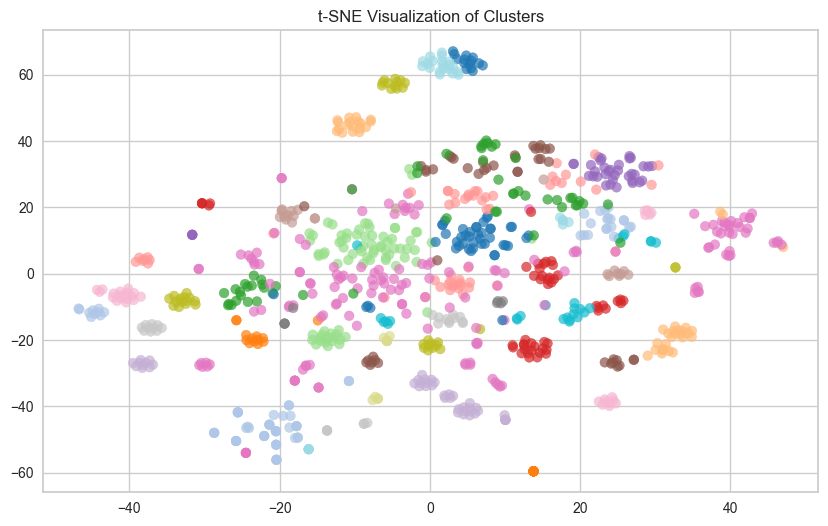

In [290]:
# Technique to visualize high-dimensional data by projecting it into a 2D space
tsne = TSNE(n_components=2, perplexity=30, random_state=0) # n_components: 2  dimensions for easy visualization, perplexity - balances local and global aspects of the data 
tsne_embeddings = tsne.fit_transform(embeddings_pca)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=cluster_labels, cmap="tab20", alpha=0.7)
plt.title("t-SNE Visualization of Clusters")
plt.show()



#### Attach KMeans PCA clusters to Questions

In [291]:
# Attach Cluster Labels to Questions
survey_questions_df["kmeans_pca_cluster"] = cluster_labels

print(f"Best Number of Clusters: {best_k}")
print("Clustered questions saved!")

Best Number of Clusters: 54
Clustered questions saved!


#### 2. Agglomerative/Hierachical Clustering

##### Each question was assigned lda_topic and bert_topic, we find the average to compute a combined_cluster balancing btn LDA and BERTtopic

In [292]:
best_k

54

In [293]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Compute average topic per question
survey_questions_df["combined_topic"] = (
    0.5 * survey_questions_df["lda_topic"] + 0.5 * survey_questions_df["bertopic_topic"]
)

# Cluster 
num_clusters = best_k
clustering_model = AgglomerativeClustering(n_clusters=num_clusters)
# Fit to predict cluster labels
survey_questions_df["combined_cluster"] = clustering_model.fit_predict(survey_questions_df[["combined_topic"]])

In [294]:
survey_questions_df.head()

,question_group,original_question,cleaned_question,sbert_embedding,lda_topic,bertopic_topic,kmeans_pca_cluster,combined_topic,combined_cluster
0,perceptions city,Q1[01][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06747598201036453, 0.03872975334525108, -0....",5,1,8,3.0,11
1,perceptions city,Q1[02][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.07277697324752808, -0.015492288395762444, -...",5,1,8,3.0,11
2,perceptions city,Q1[03][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.011186150833964348, 0.033436648547649384, -...",5,1,8,3.0,11
3,perceptions city,Q1[04][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06636805087327957, 0.04292367771267891, -0....",5,1,8,3.0,11
4,perceptions city,Q1[05][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06536620855331421, 0.06463699787855148, -0....",5,1,8,3.0,11


##### Visualize Hierachical Clustering Dendrogram

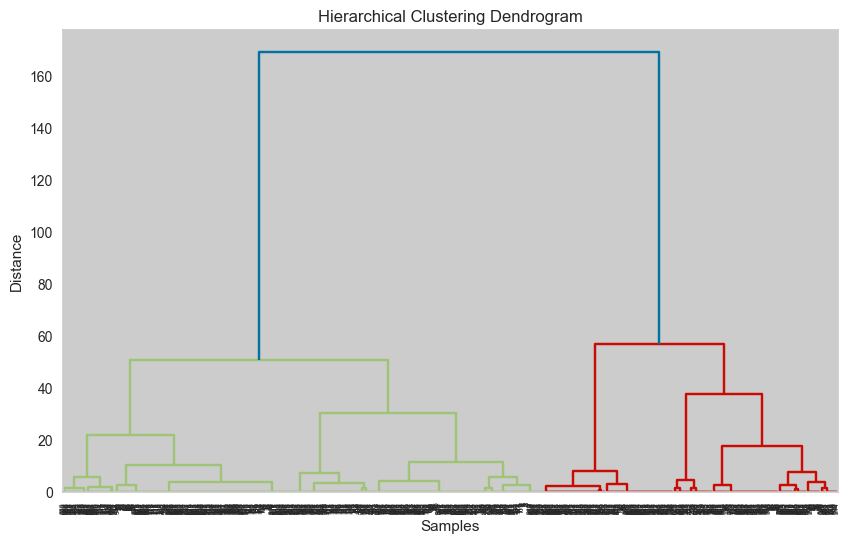

In [295]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# Convert to NumPy array for linkage
X = survey_questions_df[["combined_topic"]].values

# Create linkage matrix using Ward’s method (same as default in AgglomerativeClustering)
Z = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


#### 3. Flattening hierachical clustering (cutting dendogram)

##### performing hierarchical clustering with a linkage matrix and then cutting it into flat clusters allows us to leverage both the detailed hierarchical relationships between data points and the practical need for a specific number of clusters. 

In [301]:
from scipy.cluster.hierarchy import linkage,fcluster

# Perform hierarchical clustering
linkage_matrix = linkage(question_embeddings, method="ward")

num_clusters = best_k
clusters = fcluster(linkage_matrix, num_clusters, criterion="maxclust")

# Assign cluster labels to questions
survey_questions_df["fcluster"] = clusters

# Save clustered questions
survey_questions_df.to_csv(clustered_questions_csv_path, index=False)

print(f"Questions clustered into {num_clusters} groups!")

Questions clustered into 54 groups!


#### Extract the Most Representative Question Per Cluster

In [302]:
display(survey_questions_df)

,question_group,original_question,cleaned_question,sbert_embedding,lda_topic,bertopic_topic,kmeans_pca_cluster,combined_topic,combined_cluster,fcluster
0,perceptions city,Q1[01][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06747598201036453, 0.03872975334525108, -0....",5,1,8,3.0,11,25
1,perceptions city,Q1[02][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.07277697324752808, -0.015492288395762444, -...",5,1,8,3.0,11,25
2,perceptions city,Q1[03][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.011186150833964348, 0.033436648547649384, -...",5,1,8,3.0,11,35
3,perceptions city,Q1[04][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06636805087327957, 0.04292367771267891, -0....",5,1,8,3.0,11,25
4,perceptions city,Q1[05][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06536620855331421, 0.06463699787855148, -0....",5,1,8,3.0,11,25
...,...,...,...,...,...,...,...,...,...,...
920,,Q23[L].What is your gender?,gender,"[0.025492887943983078, 0.0570518784224987, -0....",3,5,47,4.0,2,42
921,,Q23x3[S].Please self-describe:,please selfdescribe,"[0.051757629960775375, -0.009391644969582558, ...",7,23,34,15.0,17,51
922,,Q24[L].Which of the following best describes y...,following best describes total annual househol...,"[-0.018905945122241974, 0.007802604231983423, ...",4,5,46,4.5,1,47
923,,Q25[L].What is your highest level of education...,highest level education attained,"[0.04632854089140892, 0.014205021783709526, -0...",2,1,34,1.5,13,51


In [303]:
def clean_original_question(question):
    if pd.isna(question):  
        return question  # Return as-is if it's NaN (missing)
    
    # Replace city names with placeholder
    for city in city_names:
        question = re.sub(rf"\b{city}\b", "[city name]", question, flags=re.IGNORECASE)
        
   # Remove patterns like 'Q16[01][K].', 'Q6[11][F].', 'Q20[N].', 'Q25[L].', 'Q19a[L].'
    question = re.sub(r'Q\d+[a-zA-Z]*\[\w+\]\.', '', question) 
    question = re.sub(r'^Q\d+[a-zA-Z]*\[\d+\]\[\w+\]\.', '', question) 
    # Remove the number inside '[number.' but keep the '[' and '.'
    question = re.sub(r'\[(\d+)\.', '[.', question)  # Converts '[11.' → '[.'
    
    # Remove 'Q16x4[T].', 'Q21x5[S].', 'Q23x3[S].' patterns
    question = re.sub(r'Q\d+x\d+\[\w+\]\.', '', question)
    
    return question

survey_questions_df = pd.DataFrame(survey_questions_df)

# Apply function to replace city names in each row
survey_questions_df["cleaned_original_question"] = survey_questions_df["original_question"].apply(clean_original_question)

# Generate Generic Survey Database based clusters

##### 1. Generate Survey Using KMeans PCA clusters and highest average similarity 

In [304]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# survey_questions_df contains:
# "sbert_embedding": a list column with SBERT embeddings,
# "kmeans_cluster": the cluster label for each question,
# "cleaned_question": the processed question text.

embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Using TSNE to reduce the dimensionality to 2 dimensions.
# - n_components=2: We want a 2D representation.
# - perplexity=30: A common value balancing local and global structure.
# - random_state=42: For reproducibility.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Create a DataFrame for plotting.
plot_df = pd.DataFrame(tsne_results, columns=["tsne1", "tsne2"])
plot_df["cluster"] = survey_questions_df["kmeans_pca_cluster"].values
plot_df["question"] = survey_questions_df["cleaned_question"].values

# Create an interactive scatter plot with Plotly.
fig = px.scatter(
    plot_df, 
    x="tsne1", 
    y="tsne2", 
    color="cluster", 
    hover_data=["question"],
    title="TSNE Visualization of Survey Question Clusters",
    labels={"tsne1": "TSNE Component 1", "tsne2": "TSNE Component 2"}
)

fig.show()


In [315]:
# Select the most central question in each cluster.
# Select the most representative question per cluster (highest avg similarity)
def get_representative_question(cluster_id):
    cluster_questions = survey_questions_df[survey_questions_df["kmeans_pca_cluster"] == cluster_id]
    
    if cluster_questions.empty:
        print("Missing Cluster_question",len(cluster_questions))
        return {
            'generic_question': None,
            'original_question': None
        }
    
    
 
    cluster_embeddings = np.array(cluster_questions["sbert_embedding"].tolist())
    
    # Compute intra-cluster similarity
    cluster_sim_matrix = cosine_similarity(cluster_embeddings)
    
    # Select question with highest avg similarity within its cluster
    avg_similarities = cluster_sim_matrix.mean(axis=1)
    best_idx = avg_similarities.argmax()
    
    cluster_questions.iloc[best_idx]["cleaned_original_question"]
    
    return {
        'generic_question':cluster_questions.iloc[best_idx]["cleaned_original_question"],
        'original_question':cluster_questions.iloc[best_idx]["original_question"],
        'question_group':cluster_questions.iloc[best_idx]["question_group"]
    }
        



# Generate generic survey question list
kmeans_generic_questions = [
    {"cluster": i,'question_group':get_representative_question(i)['question_group'], "generic_question": get_representative_question(i)['generic_question'],'original_question':get_representative_question(i)['original_question']}
    for i in range(1, num_clusters)
]
display(kmeans_generic_questions)

[{'cluster': 1,
  'question_group': 'please answer either yes following questions',
  'generic_question': 'Please answer either "Yes" or "No" to each of the following questions. [. Are you able to get help from either family, friends, or neighbors in time of need?]',
  'original_question': 'Q20[03][F].Please answer either "Yes" or "No" to each of the following questions. [3. Are you able to get help from either family, friends, or neighbors in time of need?]'},
 {'cluster': 2,
  'question_group': '',
  'generic_question': 'Please rate your satisfaction with each of the following parks and recreation items. [. Number of city parks]',
  'original_question': 'Q15[02][F].Please rate your satisfaction with each of the following parks and recreation items. [02. Number of city parks]'},
 {'cluster': 3,
  'question_group': '',
  'generic_question': 'Which of the following are your primary sources of information about City issues, services, and events?  [Other]',
  'original_question': 'Q15[11]

##### 2. Generic Survey Using Combined Topic Clusters (lda_topic,bert_topic) against agglomerative/Hierachical clustering

In [316]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# survey_questions_df contains:
# "sbert_embedding": a list column with SBERT embeddings,
# "kmeans_cluster": the cluster label for each question,
# "cleaned_question": the processed question text.

# Convert the list of embeddings to a NumPy array.
embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Use TSNE to reduce the dimensionality to 2 dimensions.
# - n_components=2: We want a 2D representation.
# - perplexity=30: A common value balancing local and global structure.
# - random_state=42: For reproducibility.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Create a DataFrame for plotting.
plot_df = pd.DataFrame(tsne_results, columns=["tsne1", "tsne2"])
plot_df["cluster"] = survey_questions_df["combined_cluster"].values
plot_df["question"] = survey_questions_df["cleaned_question"].values

# Create an interactive scatter plot with Plotly.
fig = px.scatter(
    plot_df, 
    x="tsne1", 
    y="tsne2", 
    color="cluster", 
    hover_data=["question"],
    title="TSNE Visualization of Survey Question Clusters",
    labels={"tsne1": "TSNE Component 1", "tsne2": "TSNE Component 2"}
)

fig.show()


In [317]:
def get_representative_question(cluster_id):
    cluster_questions = survey_questions_df[survey_questions_df["combined_cluster"] == cluster_id]
    
    if cluster_questions.empty:
        print("Missing Cluster_question",len(cluster_questions))
        return {
            'generic_question': None,
            'original_question': None
        }
    cluster_embeddings = np.array(cluster_questions["sbert_embedding"].tolist())
    
    # Compute intra-cluster similarity
    cluster_sim_matrix = cosine_similarity(cluster_embeddings)
    
    # Select question with highest avg similarity within its cluster
    avg_similarities = cluster_sim_matrix.mean(axis=1)
    best_idx = avg_similarities.argmax()
    
    cluster_questions.iloc[best_idx]["cleaned_original_question"]
    
    return {
        'generic_question':cluster_questions.iloc[best_idx]["cleaned_original_question"],
        'original_question':cluster_questions.iloc[best_idx]["original_question"],
        'question_group':cluster_questions.iloc[best_idx]["question_group"]

    }
        



# Generate generic survey question list
combined_topic_generic_questions = [
    {"cluster": i,'question_group':get_representative_question(i)['question_group'], "generic_question": get_representative_question(i)['generic_question'],'original_question':get_representative_question(i)['original_question']}
    for i in range(1, num_clusters)
]
display(combined_topic_generic_questions)

[{'cluster': 1,
  'question_group': '',
  'generic_question': 'Please rate your satisfaction with the following public safety services provided by the City of [city name]. [. The visibility of police in retail areas]',
  'original_question': 'Q21[02][F].Please rate your satisfaction with the following public safety services provided by the City of Olathe. [02. The visibility of police in retail areas]'},
 {'cluster': 2,
  'question_group': '',
  'generic_question': 'Including yourself, how many persons in your household are in each of the following age groups? [55-64 years:]',
  'original_question': 'Q29[09][K].Including yourself, how many persons in your household are in each of the following age groups? [55-64 years:]'},
 {'cluster': 3,
  'question_group': '',
  'generic_question': 'Which of the following best describes your race/ethnicity? [Prefer not to say]',
  'original_question': 'Q26[88][M].Which of the following best describes your race/ethnicity? [Prefer not to say]'},
 {'clu

##### 3. Generate Survey Using Fcluster clusters and highest average similarity 

In [318]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# survey_questions_df contains:
# "sbert_embedding": a list column with SBERT embeddings,
# "kmeans_cluster": the cluster label for each question,
# "cleaned_question": the processed question text.

# Convert the list of embeddings to a NumPy array.
embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Use TSNE to reduce the dimensionality to 2 dimensions.
# - n_components=2: We want a 2D representation.
# - perplexity=30: A common value balancing local and global structure.
# - random_state=42: For reproducibility.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Create a DataFrame for plotting.
plot_df = pd.DataFrame(tsne_results, columns=["tsne1", "tsne2"])
plot_df["cluster"] = survey_questions_df["fcluster"].values
plot_df["question"] = survey_questions_df["cleaned_original_question"].values

# Create an interactive scatter plot with Plotly.
fig = px.scatter(
    plot_df, 
    x="tsne1", 
    y="tsne2", 
    color="cluster", 
    hover_data=["question"],
    title="TSNE Visualization of Survey Question Clusters",
    labels={"tsne1": "TSNE Component 1", "tsne2": "TSNE Component 2"}
)

fig.show()


In [319]:
# Select the most central question in each cluster.
# Select the most representative question per cluster (highest avg similarity)
def get_representative_question(cluster_id):
    cluster_questions = survey_questions_df[survey_questions_df["fcluster"] == cluster_id]
     
    if cluster_questions.empty:
        print("Cluster_question",len(cluster_questions))
        return {
            'generic_question': None,
            'original_question': None
        }
    cluster_embeddings = np.array(cluster_questions["sbert_embedding"].tolist())
    
    # Compute intra-cluster similarity
    cluster_sim_matrix = cosine_similarity(cluster_embeddings)
    
    # Select question with highest avg similarity within its cluster
    avg_similarities = cluster_sim_matrix.mean(axis=1)
    best_idx = avg_similarities.argmax()
    
    cluster_questions.iloc[best_idx]["cleaned_original_question"]
    
    return {
        'generic_question':cluster_questions.iloc[best_idx]["cleaned_original_question"],
        'original_question':cluster_questions.iloc[best_idx]["original_question"],
        'question_group':cluster_questions.iloc[best_idx]["question_group"]
    }
        



# Generate generic survey question list
fcluster_generic_questions = [
    {"cluster": i,'question_group':get_representative_question(i)['question_group'], "generic_question": get_representative_question(i)['generic_question'],'original_question':get_representative_question(i)['original_question']}
    for i in range(1, num_clusters + 1)
]
display(fcluster_generic_questions)

[{'cluster': 1,
  'question_group': '',
  'generic_question': "Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]",
  'original_question': "Q8[02][F].Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]"},
 {'cluster': 2,
  'question_group': '',
  'generic_question': 'Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:]',
  'original_question': 'Q2[01][F].Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:]'},
 {'cluster': 3,
  'question_group': '',
  'generic_question': 'Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:]',
  'original_question': 'Q2[02][F].Which THREE of the items listed in Question 1 do you think should receive

### Choose best generic question cluster to apply

In [326]:
# Choose best questions from (kmeans_generic_questions,fcluster_generic_questions,combined_topic_generic_questions)
generic_questions = fcluster_generic_questions

In [327]:
def add_answer_options(df, generic_questions):
    max_options = 10  # Maximum number of answer options to store

    for i, question in enumerate(generic_questions):
        if 'original_question' in question:
            original_question_text = question['original_question']
            
            # Ensure the column exists in df
            if original_question_text in df.columns:
                # Get unique answer options
                answer_options = df[original_question_text].dropna().unique().tolist()
                
                print(f"Processing question: {original_question_text}")
                print("Answer options found:", len(answer_options))
                
                # Create a dictionary of answer option columns (up to max_options)
                option_columns = {f"option_{j+1}": (answer_options[j] if j < len(answer_options) else None) for j in range(max_options)}

                # Update the dictionary at the respective index
                generic_questions[i].update(option_columns)

add_answer_options(merged_df, generic_questions)

Processing question: Q8[02][F].Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]
Answer options found: 21
Processing question: Q2[01][F].Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:]
Answer options found: 12
Processing question: Q2[02][F].Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:]
Answer options found: 11
Processing question: Q26[06][M].Which of the following best describes your race/ethnicity? [Hispanic, Spanish, or Latino/a/x]
Answer options found: 2
Processing question: Q26[03][M].Which of the following best describes your race/ethnicity? [American Indian or Alaska Native]
Answer options found: 2
Processing question: Q26[99][M].Which of the following best describes your race/ethnicity? [Other]
Answer options found: 2
Processing question: Q15[1

In [328]:
generic_questions

[{'cluster': 1,
  'question_group': '',
  'generic_question': "Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]",
  'original_question': "Q8[02][F].Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]",
  'option_1': '09. Maintenance of infrastructure (e.g., city streets and sidewalks)',
  'option_2': '20. 311/Service request process (call to report problem)',
  'option_3': '11. Police services',
  'option_4': '03. Neighborhood code enforcement (e.g., high weeds, litter, blight)',
  'option_5': '01. Ambulance/emergency medical services',
  'option_6': '19. Social services (community centers, child care programs, homeless programs, senior programs)',
  'option_7': '06. Fire services',
  'option_8': '17. Dallas Love Field Airport',
  'option_9': '07. Solid waste services (e.g., garbage and recycling collection)',
  'option_10': '10. Park and recreation system'},
 {'cluster': 2,
  'question_group':

In [329]:
# Convert to DataFrame
generic_questions_df = pd.DataFrame(generic_questions)

display(generic_questions_df.sample(10))

,cluster,question_group,generic_question,original_question,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
1,2,,Which THREE of the City services listed in Que...,Q2[01][F].Which THREE of the City services lis...,01. Overall quality of police service,03. Overall efforts by the City to ensure the ...,02. Overall quality of fire services,06. Overall flow of traffic and congestion man...,07. Overall quality of stormwater management i...,"04. Overall maintenance of City streets, sidew...",12. Wastewater/sanitary sewer services,05. Overall effectiveness of communication by ...,08. Overall quality of parks and recreation pr...,10. Overall enforcement of local codes and ord...
42,43,,Please rate your level of agreement with each ...,Q14[01][F].Please rate your level of agreement...,Disagree,Agree,Strongly Disagree,Strongly Agree,Don't Know,None,None,None,None,None
39,40,,Please rate your satisfaction with each of the...,Q4[01][F].Please rate your satisfaction with e...,Satisfied,Very Satisfied,Neutral,Don't Know,Dissatisfied,Very Dissatisfied,None,None,None,None
31,32,parks recreation,Parks and Recreation. Please rate the City's p...,Q11[07][F].Parks and Recreation. Please rate t...,Good,Fair,Excellent,Poor,Don't Know,None,None,None,None,None
4,5,,Which of the following best describes your rac...,Q26[03][M].Which of the following best describ...,No,Yes,None,None,None,None,None,None,None,None
11,12,,"Thinking of your own life, please check if any...","Q20a[10][M].Thinking of your own life, please ...",Yes,No,None,None,None,None,None,None,None,None
38,39,,Please CHECK ALL of the following items that w...,Q31[03][M].Please CHECK ALL of the following i...,No,Yes,None,None,None,None,None,None,None,None
27,28,,Please rate your satisfaction with each of the...,Q15[02][F].Please rate your satisfaction with ...,Satisfied,Very Satisfied,Neutral,Dissatisfied,Very Dissatisfied,Don't Know,None,None,None,None
47,48,,Please rate the performance of the City employ...,Q20a[03][F].Please rate the performance of the...,Excellent,Good,Fair,Poor,Don't know,None,None,None,None,None
53,54,,Please rate your satisfaction with each of the...,Q9[06][F].Please rate your satisfaction with e...,Very Satisfied,Satisfied,Neutral,Don't Know,Dissatisfied,Very Dissatisfied,None,None,None,None


#### Save final generic survey question set

In [330]:
# Save final generic survey question set
generic_questions_df.to_csv(RawGenericSurvey_csv_path, index=False)

gen_df = generic_questions_df.drop(columns=["original_question","cluster"])
gen_df.to_csv(GenericSurvey_csv_path, index=False)

print(f"✅ Created {len(generic_questions_df)} Generic Survey Questions!")

✅ Created 54 Generic Survey Questions!


## Generic Survey Refinement with AI

In [347]:
import requests
import json

# Variables for local LLM Studio server instance
LMStudio_API_URL = "http://localhost:1234/v1/chat/completions"
API_HEADERS = {"Content-Type": "application/json"}

In [394]:
def refine_questions(questions):
    # Convert the list of questions into a formatted bullet list.
    question_list_str = "\n".join(f"- {q}" for q in questions)
    
    prompt = [
        {
            "role": "system",
            "content": (
                "You are an expert survey designer. Take each of these generic survey questions, "
                "polish them for clarity and conciseness, and then provide exactly five "
                "multiple‑choice options that span the likely range of answers."
                "You must ensure the JSON array is complete and properly closed with ']'."
            )
        },
        {
            "role": "user",
            "content": (
                "Return ONLY a JSON array of objects in this exact format (don’t include any extra text):\n"
                "[\n"
                "  {\n"
                "    \"group\": \"Refined group/category of question e.g perception, maitenence, security,parks and recreation, satisfaction etc.\",\n"
                "    \"question\": \"Refined question text\",\n"
                "    \"options\": [\"Option 1\", \"Option 2\", \"Option 3\", \"Option 4\", \"Option 5\"]\n"
                "  },\n"
                "  … more question objects …\n"
                "]\n\n"
                "**Input Questions:**\n"
                f"{question_list_str}"
            )
        }
    ]

    payload = {
        "model": "llama-3.2-3b-instruct",
        "messages": prompt,
        "temperature": 0.7,
        "max_tokens": -1  
    }

    try:
        response = requests.post(LMStudio_API_URL, headers=API_HEADERS, json=payload)
        response.raise_for_status()
        response_data = response.json()
        response_text = response_data["choices"][0]["message"]["content"]
        response_text_cleaned = response_text.strip('```json').strip('```').strip()

        # Extract JSON array
        # json_match = re.search(r'(\[.*\])', response_text_cleaned, re.DOTALL)
        json_match = re.search(r'(\[\s*{.*?}\s*\])', response_text_cleaned, re.DOTALL)

        if json_match:
            json_output = json_match.group(0)
            return json.loads(json_output)
        else:
            print(f"Invalid JSON response: {response_text}")
            return None

    except requests.exceptions.RequestException as req_err:
        print(f"Request error refining questions: {req_err}")
        return None
    except json.JSONDecodeError as json_err:
        print(f"JSON decoding error: {json_err}")
        return None
    except Exception as e:
        print(f"Unexpected error refining questions: {e}")
        return None


In [395]:
generic_questions_df = pd.read_csv(GenericSurvey_csv_path)
refined = refine_questions(generic_questions_df["generic_question"])

In [396]:
if refined:
    rows = []
    for item in refined:
        row = {"question_group": item["group"]}
        row["generic_question"] = item["question"]
        # Map options into separate columns
        for i, opt in enumerate(item["options"], start=1):
            row[f"option_{i}"] = opt
        # If fewer than 5 options, fill the rest with None
        for j in range(len(item["options"]) + 1, 6):
            row[f"option_{j}"] = None
        rows.append(row)

    refined_df = pd.DataFrame(rows)
    # Write to CSV
    refined_df.to_csv(RefinedSurvey_csv_path, index=False)
    print(f"Refined questions written to {RefinedSurvey_csv_path}")
else:
    print("⚠️ No refined questions returned.")

Refined questions written to /Users/tiruskimani/MSDATA/capstone/etc_database_recon/output/RefinedSurvey.csv


In [397]:
refined_df

,question_group,generic_question,option_1,option_2,option_3,option_4,option_5
0,Parks and Recreation,Which three of the following types of parks wo...,Parks for children,Parks with walking trails,Parks with sports facilities,Other,None
1,Code Enforcement,How would you rate the effectiveness of our co...,Very effective,Somewhat effective,Not very effective,Not at all effective,None
2,Recycling,How would you rate the overall quality of our ...,Excellent,Good,Fair,Poor,None
3,Transportation,How safe do you feel when walking to work or s...,Very safe,Somewhat safe,Not very safe,Not at all safe,None
4,Customer Service,How would you rate the quality of customer ser...,Excellent,Good,Fair,Poor,None
5,Economic Development,Which two of the following benefits of economi...,Job creation,Increased property values,None,None,None
6,Transportation Network,How would you rate the safety and accessibilit...,Excellent,Good,Fair,Poor,None
7,Public Safety,How would you rate the effectiveness of our pu...,Very effective,Somewhat effective,Not very effective,Not at all effective,None
8,Community Involvement,How likely are you to get involved in local ac...,Very likely,Somewhat likely,Not very likely,Not at all likely,None
9,Quality of Life,How would you rate the overall quality of life...,Excellent,Good,Fair,Poor,None


# Building the Similarity Algorithm

#### Develop Matching & Ranking Logic

##### Compute Similarity scores

In [488]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load generic survey questions
generic_df = pd.read_csv(GenericSurvey_csv_path)
cleaned_clustered_df = pd.read_csv(clustered_questions_csv_path)

# Prepare data
historical_questions = cleaned_clustered_df["cleaned_question"].tolist()
generic_questions = generic_df["generic_question"].tolist()
question_group = generic_df["question_group"].tolist()

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(historical_questions + generic_questions)

# Separate matrices
historical_tfidf = tfidf_matrix[: len(historical_questions)]
generic_tfidf = tfidf_matrix[len(historical_questions) :]

# Compute similarity
similarity_scores = cosine_similarity(historical_tfidf, generic_tfidf)

# Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity_scores, index=historical_questions, columns=[generic_questions,question_group]
)

# Save similarity matrix
similarity_df.to_csv(similarity_scores_csv_path)

print("Similarity matrix saved!")


Similarity matrix saved!


In [489]:
similarity_df.sample(10)

,Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:],Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:],Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:],"Which of the following best describes your race/ethnicity? [Hispanic, Spanish, or Latino/a/x]",Which of the following best describes your race/ethnicity? [American Indian or Alaska Native],Which of the following best describes your race/ethnicity? [Other],"Which of the following are your primary sources of information about City issues, services, and events? [Other]","Please CHECK ALL of the sources of information you use to get information about City services, news, and events? [. Other]",Please CHECK ALL of the following information sources you have used to get information about the City of [city name] during the past year. [Other],Please CHECK ALL of the following that you have done in [city name] over the past year. [Visited City government offices],...,"To meet the needs of future generations, the City is considering changes to the transportation infrastructure and network to better accommodate walking, biking, using public transit and charging electric vehicles. Do you support the City's transportation network to better accommodate multimodal transportation by... [Providing safe walking options to and from home, work, school, parks, grocery stores, etc.]","If you had a budget of $100 for services provided by the City of Riveria Beach, how would you allocate the funds among these categories? [Please be sure your total adds up to $100.] [Parks, Golf, and Open Spaces (including park, outdoor athletic fields and courts, trails, golf, open space, and trails.)]",What is your total annual household income?,Please rate the performance of the City employees who helped you the last time you contacted the City in the following areas. [. Courtesy],Please indicate how likely you would be to recommend your community. [. Recommend the community as a place to live],Do you own or rent your current residence?,How many persons in your household are employed in each of the following areas? [Within the City limits of [city name]:],Please rate your satisfaction with each of the following code enforcement items. [. Enforcing the maintenance of commercial property in your neighborhood],Please rate your satisfaction with each of the following items concerning your trash service. [. City efforts to keep you informed about trash removal issues],Please rate your satisfaction with each of the following items concerning your recycling service. [. Overall quality of the City's curbside recycling program]
,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,meet needs future generations city considering changes transportation infrastructure network better accommodate walking biking using public transit charging electric vehicles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
please rate satisfaction following services provided city [city name] 5 efforts local government area prevent crime,0.084500,0.092655,0.031666,0.009088,0.008586,0.012510,0.081945,0.058315,0.072313,0.239020,...,0.017823,0.040890,0.0,0.074244,0.000000,0.0,0.073132,0.049251,0.159607,0.063373
please rate satisfaction following items concerning recycling service 6 overall quality citys curbside recycling program,0.000000,0.000000,0.030339,0.008648,0.008170,0.011905,0.012306,0.000000,0.010830,0.009993,...,0.000000,0.000000,0.0,0.022242,0.000000,0.0,0.010952,0.073497,0.212432,0.976618
please rate satisfaction public safety services listed 3 quality emergency medical services,0.204734,0.149496,0.071127,0.000000,0.000000,0.000000,0.089448,0.075583,0.000000,0.000000,...,0.028787,0.026497,0.0,0.018039,0.000000,0.0,0.000000,0.050548,0.039161,0.099063
items selected would rate overall performance 04 customer service provided city emplo

### Confidence Ranking using the similarity scores

In [490]:
# Setting similarity threshold for ranks 80%- high & 70 % - medium
HIGH_CONFIDENCE_THRESHOLD = 0.65
MEDIUM_CONFIDENCE_THRESHOLD = 0.45


In [491]:
# Define thresholds
def classify_confidence(score):
    if score > HIGH_CONFIDENCE_THRESHOLD:
        return "High"
    elif score > MEDIUM_CONFIDENCE_THRESHOLD:
        return "Medium"
    else:
        return "Low"

matches = []
for hist_idx, hist_question in enumerate(historical_questions):
    best_match_idx = np.argmax(similarity_scores[hist_idx])
    best_match_score = similarity_scores[hist_idx][best_match_idx]
    best_match_question = generic_questions[best_match_idx]

    matches.append(
        {
            "historical_question": hist_question,
            "best_generic_question": best_match_question,
            "similarity_score": best_match_score,
            "confidence_level": classify_confidence(best_match_score),

        }
    )

# Convert to DataFrame
matches_df = pd.DataFrame(matches)
# add rank
matches_df["Rank"] = matches_df["similarity_score"].rank(method="dense", ascending=False).astype(int)

# Save results
matched_path = os.path.join(output_dir, 'matched_questions.csv');

matches_df.to_csv(matched_path, index=False)

print("✅ Matches Classified & Saved!")
display(matches_df)


✅ Matches Classified & Saved!


,historical_question,best_generic_question,similarity_score,confidence_level,Rank
0,please rate following items circling correspon...,Please rate the City of [city name] with regar...,0.487664,Medium,405
1,please rate following items circling correspon...,Please rate the City of [city name] with regar...,0.409926,Low,491
2,please rate following items circling correspon...,Please indicate the extent to which you think ...,0.384301,Low,526
3,please rate following items circling correspon...,Please indicate the extent to which you think ...,0.463036,Medium,433
4,please rate following items circling correspon...,Please indicate the extent to which you think ...,0.424847,Low,471
...,...,...,...,...,...
920,gender,What is your gender?,1.000000,High,3
921,please selfdescribe,Which FOUR of the services listed above do you...,0.000000,Low,782
922,following best describes total annual househol...,What is your total annual household income?,0.884723,High,40
923,highest level education attained,Please rate your level of agreement with each ...,0.173998,Low,719


### Question Matching and Grouping

In [492]:
len(similarity_df)

925

In [493]:
similarity_df

,Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:],Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:],Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:],"Which of the following best describes your race/ethnicity? [Hispanic, Spanish, or Latino/a/x]",Which of the following best describes your race/ethnicity? [American Indian or Alaska Native],Which of the following best describes your race/ethnicity? [Other],"Which of the following are your primary sources of information about City issues, services, and events? [Other]","Please CHECK ALL of the sources of information you use to get information about City services, news, and events? [. Other]",Please CHECK ALL of the following information sources you have used to get information about the City of [city name] during the past year. [Other],Please CHECK ALL of the following that you have done in [city name] over the past year. [Visited City government offices],...,"To meet the needs of future generations, the City is considering changes to the transportation infrastructure and network to better accommodate walking, biking, using public transit and charging electric vehicles. Do you support the City's transportation network to better accommodate multimodal transportation by... [Providing safe walking options to and from home, work, school, parks, grocery stores, etc.]","If you had a budget of $100 for services provided by the City of Riveria Beach, how would you allocate the funds among these categories? [Please be sure your total adds up to $100.] [Parks, Golf, and Open Spaces (including park, outdoor athletic fields and courts, trails, golf, open space, and trails.)]",What is your total annual household income?,Please rate the performance of the City employees who helped you the last time you contacted the City in the following areas. [. Courtesy],Please indicate how likely you would be to recommend your community. [. Recommend the community as a place to live],Do you own or rent your current residence?,How many persons in your household are employed in each of the following areas? [Within the City limits of [city name]:],Please rate your satisfaction with each of the following code enforcement items. [. Enforcing the maintenance of commercial property in your neighborhood],Please rate your satisfaction with each of the following items concerning your trash service. [. City efforts to keep you informed about trash removal issues],Please rate your satisfaction with each of the following items concerning your recycling service. [. Overall quality of the City's curbside recycling program]
,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,meet needs future generations city considering changes transportation infrastructure network better accommodate walking biking using public transit charging electric vehicles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
please rate following items circling corresponding number 01 [city name] place live,0.027925,0.040781,0.062864,0.011973,0.011312,0.016482,0.039845,0.019272,0.055134,0.050877,...,0.011741,0.006756,0.000000,0.064306,0.209571,0.0,0.055758,0.070511,0.068811,0.073060
please rate following items circling corresponding number 02 neighborhood place live,0.000000,0.000000,0.039390,0.011228,0.010608,0.015456,0.015977,0.000000,0.014060,0.012975,...,0.000000,0.000000,0.000000,0.028878,0.196529,0.0,0.014219,0.197640,0.051227,0.054391
please rate following items circling corresponding number 03 [city name] place raise children,0.023073,0.033696,0.051943,0.009893,0.009347,0.013618,0.032922,0.015923,0.045555,0.042038,...,0.009701,0.005582,0.000000,0.053134,0.093607,0.0,0.046071,0.058261,0.056856,0.060367
please rate following items circling corresponding number 04 [city name] place work,0.027800,0.040600,0.062584,0.011920,0.011261,0.01640

In [494]:
high_confidence_questions = []
medium_confidence_questions = []
low_confidence_questions = []

In [495]:
import pandas as pd

# Initialize a list to store the ranking results.
ranking_results = []

# Iterate over each historical question (each row in the similarity_df)
for hist_question_id, row in similarity_df.iterrows():
    # Sort the generic questions by descending similarity score.
    sorted_matches = row.sort_values(ascending=False)

    
    # Enumerate through the sorted matches, starting rank at 1.
    for rank, (generic_question, similarity_score) in enumerate(sorted_matches.items(), start=1):
        ranking_results.append({
            "Question_Group": generic_question[1],
            "Historical_Question": hist_question_id,
            "Generic_Question": generic_question[0],
            "Similarity_Score": similarity_score,
            "Confidence_Level": classify_confidence(similarity_score),
            "Rank": rank
        })

# Convert the results into a DataFrame for easy viewing/analysis.
ranking_df = pd.DataFrame(ranking_results)

# Optionally, you can filter or group the results.
# For example, to view the top-ranked generic question for each historical question:
top_ranked = ranking_df[ranking_df["Rank"] == 1]
print(top_ranked)


      Question_Group                                Historical_Question  \
0                NaN  please rate following items circling correspon...   
54               NaN  please rate following items circling correspon...   
108              NaN  please rate following items circling correspon...   
162              NaN  please rate following items circling correspon...   
216              NaN  please rate following items circling correspon...   
...              ...                                                ...   
49680            NaN                                            gender    
49734            NaN                               please selfdescribe    
49788            NaN  following best describes total annual househol...   
49842            NaN                  highest level education attained    
49896            NaN   suggestions city would like make please provide    

                                        Generic_Question  Similarity_Score  \
0      Please rate th

In [496]:
ranking_df.sample(10)

,Question_Group,Historical_Question,Generic_Question,Similarity_Score,Confidence_Level,Rank
28432,NaN,two following benefits economic development im...,Please rate your satisfaction with each of the...,0.017479,Low,29
4372,NaN,items selected would rate overall performance ...,"Please define ""Other.""",0.000000,Low,53
40182,NaN,different housing types already offered [city ...,When you think about the number and variety of...,0.064408,Low,7
9809,NaN,please rate performance city employees helped ...,Please rate your satisfaction with each of the...,0.027383,Low,36
44388,NaN,please rate satisfaction following services pr...,Please rate your satisfaction with the followi...,0.803363,High,1
11889,NaN,please rate overall satisfaction major categor...,Please rate your satisfaction with each of the...,0.173320,Low,10
38681,NaN,following primary sources information city iss...,Please rate your level of agreement with each ...,0.085866,Low,18
30258,NaN,please define,If you had a budget of $100 for services provi...,0.000000,Low,19
5345,NaN,items selected would rate overall performance ...,What is your age?,0.000000,Low,54
29885,city aware shortage housing nationwide locally,please check following done [city name] past y...,The City is aware of a shortage of housing nat...,0.059276,Low,24


In [497]:
ranking_path = os.path.join(output_dir, 'ranking.csv');
ranking_df.to_csv(ranking_path, index=False);

In [498]:
for idx, row in similarity_df.iterrows():
    max_similarity = row.max()
    best_match = row.idxmax()
    best_match = best_match[0] 
    best_match_group = best_match[2] if len(best_match) > 1 else ''
    
    
    if max_similarity >= HIGH_CONFIDENCE_THRESHOLD:
        high_confidence_questions.append((idx,best_match, max_similarity, "High"))
    elif max_similarity >= MEDIUM_CONFIDENCE_THRESHOLD:
        medium_confidence_questions.append((idx, best_match, max_similarity, "Medium"))
    else:
        low_confidence_questions.append((idx,best_match , max_similarity, "Low"))

In [499]:
# Convert to DF
high_df = pd.DataFrame(high_confidence_questions, columns=["Historical Question", "Matched Template Question", "Similarity Score", "Confidence Level"])
medium_df = pd.DataFrame(medium_confidence_questions, columns=["Historical Question", "Matched Template Question", "Similarity Score", "Confidence Level"])
low_df = pd.DataFrame(low_confidence_questions, columns=["Historical Question", "Matched Template Question", "Similarity Score", "Confidence Level"])
high_df.sample(20)

,Historical Question,Matched Template Question,Similarity Score,Confidence Level
87,thinking life please check following obstacles...,"Thinking of your own life, please check if any...",0.840104,High
145,please indicate city [city name] compares citi...,Please indicate how the City of [city name] co...,0.925444,High
141,please check following information sources cur...,Please CHECK ALL of the following information ...,0.766884,High
4,please rate following characteristics relate [...,Please rate each of the following characterist...,0.921260,High
76,two parks recreation items listed question 15 ...,Which THREE of the items listed in Question 1 ...,0.703611,High
88,thinking life please check following obstacles...,"Thinking of your own life, please check if any...",0.840104,High
81,thinking life please check following obstacles...,"Thinking of your own life, please check if any...",0.840104,High
214,three maintenance items listed question 10 thi...,Which THREE of the items listed in Question 1 ...,0.898637,High
205,please rate satisfaction following code enforc...,Please rate your satisfaction with each of the...,0.735148,High
185,age,What is your age?,1.000000,High


In [500]:


high_df = high_df.sort_values(by="Similarity Score", ascending=False).reset_index(drop=True)
high_df["Rank"] = high_df["Similarity Score"].rank(method="dense", ascending=False).astype(int)

medium_df = medium_df.sort_values(by="Similarity Score", ascending=False).reset_index(drop=True)
medium_df["Rank"] = medium_df["Similarity Score"].rank(method="dense", ascending=False).astype(int)

low_df = low_df.sort_values(by="Similarity Score", ascending=False).reset_index(drop=True)
low_df["Rank"] = low_df["Similarity Score"].rank(method="dense", ascending=False).astype(int)


# save matches
high_df.to_csv(high_match_csv_path, index=False);
medium_df.to_csv(medium_match_csv_path, index=False);
low_df.to_csv(low_match_csv_path, index=False);




In [501]:
# Display results
print(f"High Confidence survey questions: {high_match_csv_path}");
display(high_df.sample(10));
print(f"Medium Confidence survey questions: {medium_match_csv_path}");
display(medium_df.sample(10));
print(f"Low Confidence survey questions: {low_match_csv_path}");
display(low_df.sample(10));

High Confidence survey questions: /Users/tiruskimani/MSDATA/capstone/etc_database_recon/output/high_matched_survey_questions.csv


,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
176,please check sources information use get infor...,Please CHECK ALL of the sources of information...,0.770359,High,119
136,three items listed question 1 think receive em...,Which THREE of the items listed in Question 1 ...,0.823130,High,85
242,please rate satisfaction following public safe...,Please rate your satisfaction with the followi...,0.717178,High,180
150,please rate level agreement following statemen...,Please rate your level of agreement with each ...,0.808595,High,97
13,age,What is your age?,1.000000,High,3
201,three maintenance items listed question 10 thi...,Which THREE of the items listed in Question 1 ...,0.756891,High,141
151,please rate satisfaction following services pr...,Please rate your satisfaction with the followi...,0.803363,High,98
267,think number variety places live work play [ci...,When you think about the number and variety of...,0.687936,High,205
17,please define,"Please define ""Other.""",1.000000,High,3
213,please check following types retail restaurant...,Please CHECK ALL of the following types of ret...,0.744831,High,153


Medium Confidence survey questions: /Users/tiruskimani/MSDATA/capstone/etc_database_recon/output/medium_matched_survey_questions.csv


,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
171,please rate satisfaction following code enforc...,Please rate your satisfaction with each of the...,0.493464,Medium,162
70,please rate following major categories service...,Please rate your overall satisfaction with maj...,0.578541,Medium,66
182,please rate satisfaction following parks recre...,Please rate your satisfaction with each of the...,0.484001,Medium,173
212,counting many people household ages 4554 ages ...,"Counting yourself, how many people in your hou...",0.458033,Medium,202
108,please rate overall satisfaction major categor...,Please rate your overall satisfaction with maj...,0.541382,Medium,104
156,members household spanish hispanic latino heri...,Which of the following best describes your rac...,0.507666,Medium,148
214,counting many people household ages 59 ages 59,"Counting yourself, how many people in your hou...",0.458033,Medium,202
92,visited [city name] park past year,Please CHECK ALL of the following that you hav...,0.559815,Medium,88
158,please rate satisfaction following code enforc...,Please rate your satisfaction with each of the...,0.505915,Medium,150
15,support citys transportation network better ac...,"To meet the needs of future generations, the C...",0.630140,Medium,16


Low Confidence survey questions: /Users/tiruskimani/MSDATA/capstone/etc_database_recon/output/low_matched_survey_questions.csv


,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
187,following best describes raceethnicity native ...,Which of the following best describes your rac...,0.285898,Low,168
73,major categories city services provided city [...,Please rate each of the following major catego...,0.388236,Low,70
233,please rate satisfaction following public safe...,Please rate your satisfaction with the followi...,0.254692,Low,201
306,please rate citys performance following areas ...,Parks and Recreation. Please rate the City's p...,0.175262,Low,270
253,please rate citys performance following areas ...,Parks and Recreation. Please rate the City's p...,0.226920,Low,221
269,items selected would rate overall performance ...,"For the items you selected, how would you rate...",0.205224,Low,236
307,please rate citys performance following areas ...,Parks and Recreation. Please rate the City's p...,0.174082,Low,271
85,please rate following characteristics relate [...,Please rate each of the following characterist...,0.374812,Low,81
43,counting many people regularly live household,"Counting yourself, how many people in your hou...",0.412280,Low,40
74,please rate citys performance following areas ...,Parks and Recreation. Please rate the City's p...,0.387627,Low,71
